# Task 2: Baseline CNN from Scratch

## Overview

This notebook trains a custom CNN architecture from scratch on the CIFAKE dataset. The baseline serves two purposes:

1. **Performance floor** — establishes the minimum AUC/accuracy that pretrained models must beat in Task 3
2. **Concept demonstration** — shows exactly what happens when you train a vision model without pretrained weights: the model learns task-relevant features but misses the low-level forensic texture patterns that ImageNet-pretrained models already encode

### Why "from scratch" matters as a comparison point

Transfer learning almost always wins for image classification. But showing *why* it wins — and quantifying the gap — is what makes your portfolio project analytically rigorous rather than just a collection of model calls.

The gap between this notebook and Task 3 is the evidence that pretrained texture detectors (from ImageNet training on millions of images) are directly useful for forensic image detection even though ImageNet contains no fake images at all.

### Architecture: 4-block CNN

```
Input (32x32x3)
    ↓
Block 1: Conv(32) → BN → ReLU → Conv(32) → BN → ReLU → MaxPool → Dropout(0.25)
    ↓
Block 2: Conv(64) → BN → ReLU → Conv(64) → BN → ReLU → MaxPool → Dropout(0.25)
    ↓
Block 3: Conv(128) → BN → ReLU → Conv(128) → BN → ReLU → MaxPool → Dropout(0.30)
    ↓
Block 4: Conv(256) → BN → ReLU → Conv(256) → BN → ReLU → GlobalAvgPool → Dropout(0.40)
    ↓
Dense(256) → BN → ReLU → Dropout(0.50) → Dense(1) → Sigmoid
```

**Design decisions explained:**
- Batch normalization after every conv: stabilizes training, allows higher learning rates
- Double conv per block: increases receptive field without aggressive pooling
- Global average pooling instead of flatten: reduces parameters, improves generalization
- Progressive dropout: higher dropout deeper in the network where overfitting risk is highest

---
## Install and Import

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, classification_report,
    precision_score, recall_score, roc_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = Path('/kaggle/working/fake_detection_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory      : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

PyTorch version : 2.10.0+cu128
Device          : cuda
GPU             : Tesla T4
GPU Memory      : 15.6 GB


---
## Dataset Class and Data Loaders

### Why we write a custom Dataset class

PyTorch's `Dataset` interface forces us to think clearly about three things:
- `__len__`: how many samples exist
- `__getitem__`: how to load and transform one sample
- Transform pipeline: what preprocessing happens at load time

Writing this explicitly — rather than using a high-level wrapper — means every transformation is visible and auditable. This matters for forensics: we need to ensure we are not accidentally destroying the subtle pixel-level signals (noise patterns, frequency content) that differentiate real from fake images.

### Augmentation strategy — what is safe and what is not

From Task 1 forensic analysis:
- **Safe**: horizontal flip (does not alter texture statistics), mild color jitter (simulates different cameras)
- **Safe**: random crop with padding (preserves local texture structure)
- **Unsafe**: JPEG compression (destroys high-frequency content and introduces its own artifacts)
- **Unsafe**: Gaussian blur (removes noise residuals — the very signal we want to detect)
- **Unsafe**: frequency domain transforms (directly destroy the FFT signals identified in Task 1)

In [2]:
DATA_DIR = Path('/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images')

class CIFAKEDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.transform = transform
        self.samples   = []
        self.labels    = []

        for label_idx, label_name in enumerate(['REAL', 'FAKE']):
            folder = root_dir / split / label_name
            for img_path in folder.glob('*.jpg'):
                self.samples.append(img_path)
                self.labels.append(label_idx)
            for img_path in folder.glob('*.png'):
                self.samples.append(img_path)
                self.labels.append(label_idx)

        self.samples = np.array(self.samples)
        self.labels  = np.array(self.labels)
        print(f'  {split:5s} — REAL: {(self.labels==0).sum():,}  '
              f'FAKE: {(self.labels==1).sum():,}  '
              f'Total: {len(self.labels):,}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# ── Transforms ────────────────────────────────────────────────────────────────
# IMPORTANT: no blur, no jpeg compression — these destroy forensic signals
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.ColorJitter(brightness=0.1, contrast=0.1,
                           saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616]),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616]),
])

print('Building datasets:')
train_ds = CIFAKEDataset(DATA_DIR, split='train', transform=train_transform)
test_ds  = CIFAKEDataset(DATA_DIR, split='test',  transform=test_transform)

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'\nBatch size    : {BATCH_SIZE}')
print(f'Train batches : {len(train_loader)}')
print(f'Test batches  : {len(test_loader)}')

Building datasets:
  train — REAL: 50,000  FAKE: 50,000  Total: 100,000
  test  — REAL: 10,000  FAKE: 10,000  Total: 20,000

Batch size    : 256
Train batches : 391
Test batches  : 79


---
## CNN Architecture

### Design rationale — every choice explained

**BatchNorm after Conv, before activation:**
Normalizes the pre-activation distribution to zero mean and unit variance. This allows much higher learning rates and makes the network less sensitive to weight initialization. Essential for training deep networks from scratch without pretrained initialization.

**Double Conv per block:**
Two 3×3 convolutions have the same receptive field as one 5×5 convolution but with fewer parameters and an extra non-linearity. This gives more expressive power per parameter count.

**Global Average Pooling instead of Flatten:**
After the 4 pooling operations, the 32×32 input becomes 2×2. Flattening gives 2×2×256 = 1,024 features. GAP averages each channel map to a scalar, giving 256 features. This reduces the parameter count of the classifier head by 4× and acts as structural regularization — the model must encode information as channel activations rather than spatial position.

**Progressive dropout rates (0.25 → 0.30 → 0.40 → 0.50):**
Early layers learn general low-level features (edges, textures) that generalize well — low dropout is appropriate. Later layers learn task-specific combinations — higher dropout prevents co-adaptation of features.

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.25):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)


class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32,  dropout=0.25),   # 32x32 → 16x16
            ConvBlock(32,  64,  dropout=0.25),   # 16x16 → 8x8
            ConvBlock(64,  128, dropout=0.30),   # 8x8   → 4x4
            ConvBlock(128, 256, dropout=0.40),   # 4x4   → 2x2
        )
        self.gap       = nn.AdaptiveAvgPool2d(1)  # 2x2 → 1x1
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.50),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


# ── Instantiate and inspect ───────────────────────────────────────────────────
model = BaselineCNN().to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')

# Verify forward pass dimensions
dummy = torch.zeros(4, 3, 32, 32).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f'Input shape  : {dummy.shape}')
print(f'Output shape : {out.shape}  (batch, logit)')

Total parameters     : 1,239,777
Trainable parameters : 1,239,777
Input shape  : torch.Size([4, 3, 32, 32])
Output shape : torch.Size([4, 1])  (batch, logit)


---
## Training Setup

### Loss function: BCEWithLogitsLoss

We output a single logit (unnormalized score) rather than a sigmoid probability. `BCEWithLogitsLoss` combines sigmoid + binary cross-entropy in a single numerically stable operation. This is always preferable to applying sigmoid manually then using `BCELoss`.

### Optimizer: AdamW

AdamW decouples weight decay from the gradient update — an improvement over Adam's L2 regularization that prevents weight decay from interfering with adaptive learning rates. With `weight_decay=1e-4`, this provides light regularization that complements dropout.

### Learning rate schedule: CosineAnnealingLR

Cosine annealing starts at `lr=3e-4` and smoothly decays to near zero over 50 epochs. This is superior to step-decay schedules because:
- No discontinuous LR drops that can destabilize training
- The slow final phase allows fine-grained convergence
- Works well with batch norm and dropout

In [5]:
EPOCHS    = 30
LR        = 3e-4
WD        = 1e-4

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f'Loss      : BCEWithLogitsLoss')
print(f'Optimizer : AdamW (lr={LR}, weight_decay={WD})')
print(f'Scheduler : CosineAnnealingLR (T_max={EPOCHS})')
print(f'Epochs    : {EPOCHS}')
print(f'Device    : {DEVICE}')

Loss      : BCEWithLogitsLoss
Optimizer : AdamW (lr=0.0003, weight_decay=0.0001)
Scheduler : CosineAnnealingLR (T_max=30)
Epochs    : 30
Device    : cuda


---
## Training and Evaluation Functions

### Why we separate train and evaluate into functions

This pattern allows the training loop to stay clean and readable. More importantly:
- `evaluate()` always runs with `torch.no_grad()` — no gradient computation means 2-3× faster inference and no memory accumulation
- Separating concerns makes it trivial to add validation-set evaluation during training without duplicating code
- The function signature makes it explicit what data goes in and what metrics come out

In [6]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds       = (torch.sigmoid(logits) > 0.5).float()
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            labels_d = labels.float().unsqueeze(1).to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels_d)
            total_loss += loss.item() * imgs.size(0)
            probs  = torch.sigmoid(logits).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds      = (all_probs > 0.5).astype(int)

    metrics = {
        'loss':      total_loss / len(all_labels),
        'accuracy':  accuracy_score(all_labels, preds),
        'auc':       roc_auc_score(all_labels, all_probs),
        'f1':        f1_score(all_labels, preds),
        'precision': precision_score(all_labels, preds),
        'recall':    recall_score(all_labels, preds),
        'probs':     all_probs,
        'labels':    all_labels,
    }
    return metrics

print('Training and evaluation functions defined.')

Training and evaluation functions defined.


---
## Training Loop

### What to watch during training

**Training vs validation loss divergence** is the clearest overfitting signal. If training loss keeps decreasing while validation loss plateaus or increases, the model is memorizing rather than generalizing.

**Accuracy plateau** around 85-88% is expected for a scratch-trained CNN on this task. The model learns macro-level differences (color statistics, broad texture patterns) but cannot learn the subtle forensic signals without the benefit of ImageNet pretraining on millions of diverse images.

**Learning rate curve** should show smooth cosine decay — no sudden jumps that indicate instability.

In [7]:
history = {k: [] for k in ['train_loss','train_acc','val_loss','val_acc','val_auc','lr']}
best_auc   = 0.0
best_epoch = 0

print(f'Training for {EPOCHS} epochs on {DEVICE}...')
print(f'{"Epoch":>5} {"TrainLoss":>10} {"TrainAcc":>10} '
      f'{"ValLoss":>10} {"ValAcc":>10} {"ValAUC":>10} {"LR":>12}')
print('-' * 75)

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE)
    val_metrics = evaluate(model, test_loader, criterion, DEVICE)
    scheduler.step()

    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_auc'].append(val_metrics['auc'])
    history['lr'].append(current_lr)

    if val_metrics['auc'] > best_auc:
        best_auc   = val_metrics['auc']
        best_epoch = epoch
        torch.save(model.state_dict(), OUTPUT_DIR / 'baseline_cnn_best.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:>5} {train_loss:>10.4f} {train_acc:>10.4f} '
              f'{val_metrics["loss"]:>10.4f} {val_metrics["accuracy"]:>10.4f} '
              f'{val_metrics["auc"]:>10.4f} {current_lr:>12.6f}')

elapsed = time.time() - start_time
print(f'\nTraining complete in {elapsed/60:.1f} minutes')
print(f'Best val AUC: {best_auc:.4f} at epoch {best_epoch}')

Training for 30 epochs on cuda...
Epoch  TrainLoss   TrainAcc    ValLoss     ValAcc     ValAUC           LR
---------------------------------------------------------------------------
    1     0.3647     0.8350     0.3150     0.8686     0.9664     0.000299
    5     0.2162     0.9141     0.2916     0.8811     0.9847     0.000280
   10     0.1843     0.9284     0.2014     0.9209     0.9873     0.000225
   15     0.1669     0.9358     0.2761     0.8946     0.9884     0.000150
   20     0.1535     0.9412     0.2716     0.8936     0.9912     0.000076
   25     0.1427     0.9455     0.2618     0.9018     0.9918     0.000021
   30     0.1404     0.9465     0.2692     0.8972     0.9921     0.000001

Training complete in 68.0 minutes
Best val AUC: 0.9922 at epoch 29


---
## Training Curves

### Reading the training curves — what to look for

**Loss curves:** Train loss should decrease smoothly. Val loss should track train loss initially, then plateau. A large gap between them = overfitting. Both high = underfitting.

**Accuracy curves:** Should increase then plateau. The plateau level is the model's effective capacity ceiling on this task.

**AUC curve:** More informative than accuracy. AUC measures ranking quality — whether the model assigns higher probabilities to genuine fakes. An AUC of 0.85+ means the model is meaningfully ranking real vs fake images. AUC of 0.50 is random.

**Learning rate curve:** Should show a smooth cosine decay from the initial value to near zero.

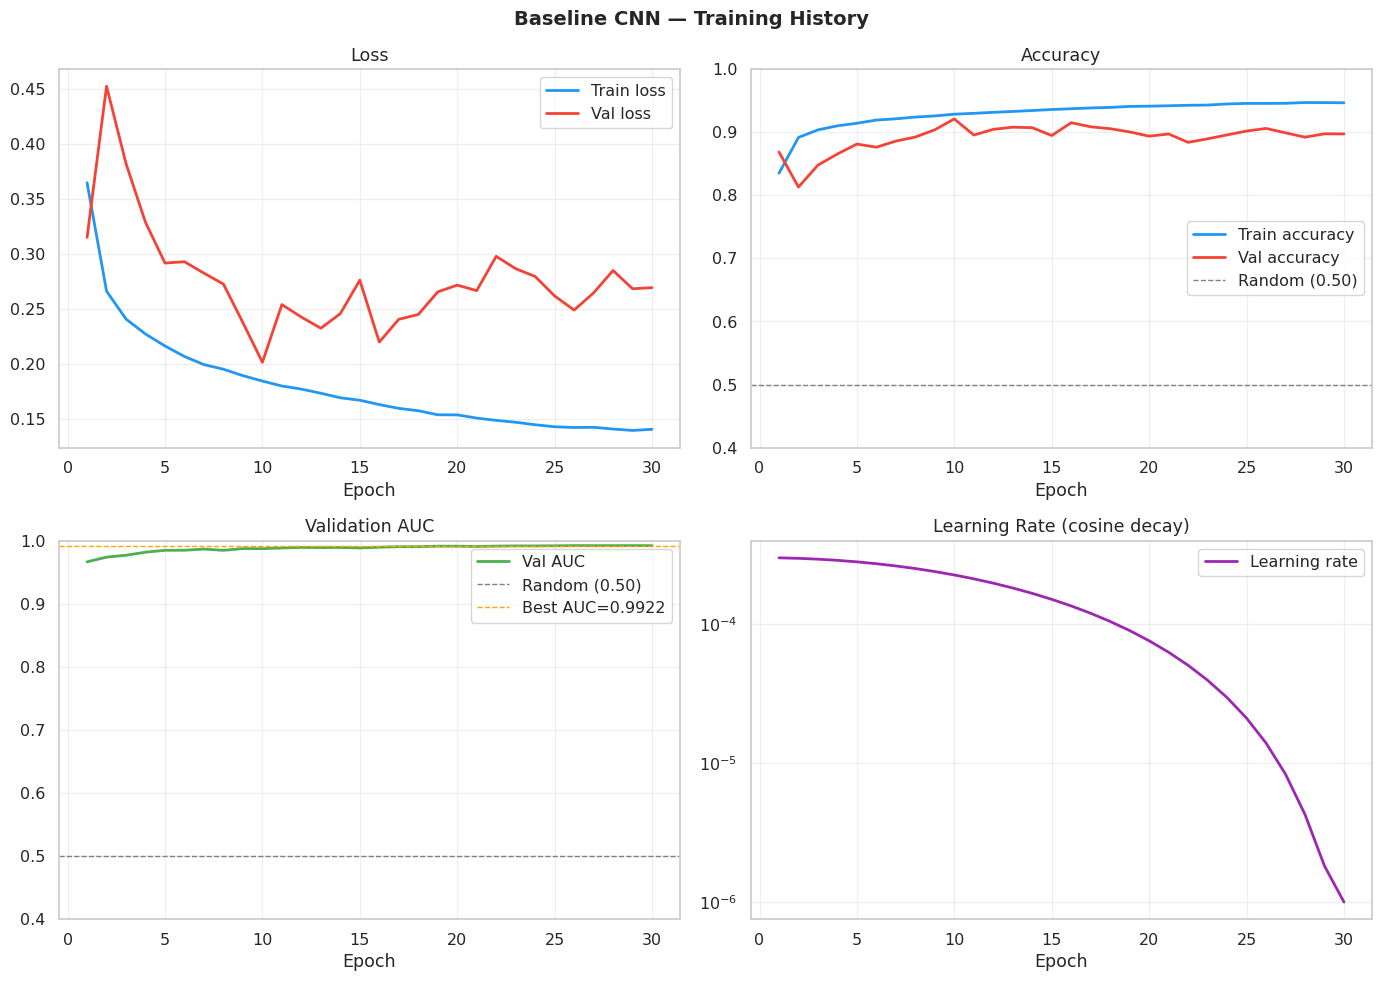

Final train accuracy : 0.9465
Final val accuracy   : 0.8972
Overfit gap          : 0.0494


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Baseline CNN — Training History', fontsize=14, fontweight='bold')
epochs_x = range(1, EPOCHS + 1)

# Loss
axes[0,0].plot(epochs_x, history['train_loss'], color='#2196F3',
               linewidth=2, label='Train loss')
axes[0,0].plot(epochs_x, history['val_loss'], color='#F44336',
               linewidth=2, label='Val loss')
axes[0,0].set_title('Loss'); axes[0,0].set_xlabel('Epoch')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# Accuracy
axes[0,1].plot(epochs_x, history['train_acc'], color='#2196F3',
               linewidth=2, label='Train accuracy')
axes[0,1].plot(epochs_x, history['val_acc'], color='#F44336',
               linewidth=2, label='Val accuracy')
axes[0,1].axhline(0.5, color='gray', linestyle='--',
                  linewidth=1, label='Random (0.50)')
axes[0,1].set_title('Accuracy'); axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylim([0.4, 1.0]); axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# AUC
axes[1,0].plot(epochs_x, history['val_auc'], color='#4CAF50',
               linewidth=2, label='Val AUC')
axes[1,0].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random (0.50)')
axes[1,0].axhline(best_auc, color='orange', linestyle='--',
                  linewidth=1, label=f'Best AUC={best_auc:.4f}')
axes[1,0].set_title('Validation AUC'); axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylim([0.4, 1.0]); axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Learning rate
axes[1,1].plot(epochs_x, history['lr'], color='#9C27B0',
               linewidth=2, label='Learning rate')
axes[1,1].set_title('Learning Rate (cosine decay)'); axes[1,1].set_xlabel('Epoch')
axes[1,1].set_yscale('log'); axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'baseline_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Overfit gap
final_gap = history['train_acc'][-1] - history['val_acc'][-1]
print(f'Final train accuracy : {history["train_acc"][-1]:.4f}')
print(f'Final val accuracy   : {history["val_acc"][-1]:.4f}')
print(f'Overfit gap          : {final_gap:.4f}')

---
## Final Model Evaluation

### Loading the best checkpoint

We trained with checkpoint saving whenever val AUC improved. Now we load the best checkpoint and run a full evaluation on the test set. This prevents the "last epoch bias" — the final epoch's weights might not be the best if training diverged slightly toward the end.

In [9]:
# Load best checkpoint
model.load_state_dict(torch.load(OUTPUT_DIR / 'baseline_cnn_best.pth'))
print(f'Loaded best model from epoch {best_epoch} (val AUC={best_auc:.4f})')

# Final evaluation
final_metrics = evaluate(model, test_loader, criterion, DEVICE)
test_probs    = final_metrics['probs']
test_labels   = final_metrics['labels']
test_preds    = (test_probs > 0.5).astype(int)

print('\n=== FINAL TEST SET RESULTS — BASELINE CNN ===')
print(f'  Accuracy  : {final_metrics["accuracy"]:.4f}')
print(f'  ROC-AUC   : {final_metrics["auc"]:.4f}')
print(f'  F1 Score  : {final_metrics["f1"]:.4f}')
print(f'  Precision : {final_metrics["precision"]:.4f}')
print(f'  Recall    : {final_metrics["recall"]:.4f}')

print('\nClassification Report:')
print(classification_report(test_labels, test_preds,
                             target_names=['REAL', 'FAKE']))

Loaded best model from epoch 29 (val AUC=0.9922)

=== FINAL TEST SET RESULTS — BASELINE CNN ===
  Accuracy  : 0.8973
  ROC-AUC   : 0.9922
  F1 Score  : 0.8863
  Precision : 0.9929
  Recall    : 0.8004

Classification Report:
              precision    recall  f1-score   support

        REAL       0.83      0.99      0.91     10000
        FAKE       0.99      0.80      0.89     10000

    accuracy                           0.90     20000
   macro avg       0.91      0.90      0.90     20000
weighted avg       0.91      0.90      0.90     20000



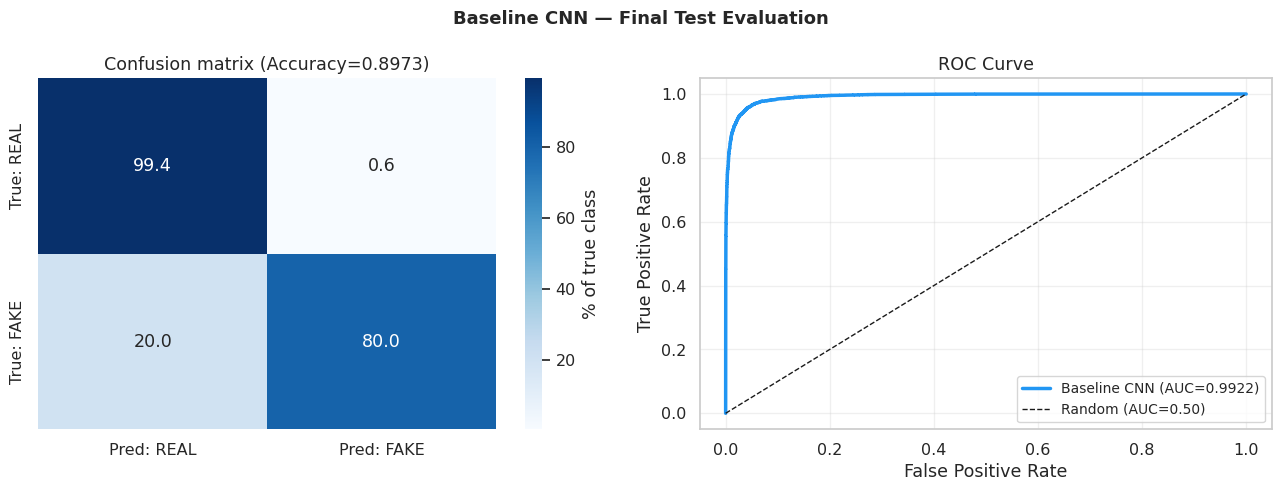

In [11]:
# Confusion matrix + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Baseline CNN — Final Test Evaluation', fontsize=13, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: REAL', 'Pred: FAKE'],
            yticklabels=['True: REAL', 'True: FAKE'],
            cbar_kws={'label': '% of true class'})
axes[0].set_title(f'Confusion matrix (Accuracy={final_metrics["accuracy"]:.4f})')

# ROC curve
fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, color='#2196F3', linewidth=2.5,
             label=f'Baseline CNN (AUC={final_metrics["auc"]:.4f})')
axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.50)')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'baseline_cnn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Score Distribution Analysis

### Why the score distribution matters

The score distribution shows how confidently the model separates real from fake images. A well-calibrated model should show:
- A peak near 0.0 for real images (confident prediction: real)
- A peak near 1.0 for fake images (confident prediction: fake)
- Minimal overlap in the middle

High overlap in the 0.3–0.7 range means the model is uncertain about many images — these are the hard cases that a more powerful model (Task 3) should handle better.

This plot also helps choose a deployment threshold. If a platform cares more about avoiding false positives (flagging real content), the threshold should be set high. If it cares more about catching fakes (recall), the threshold should be set low.

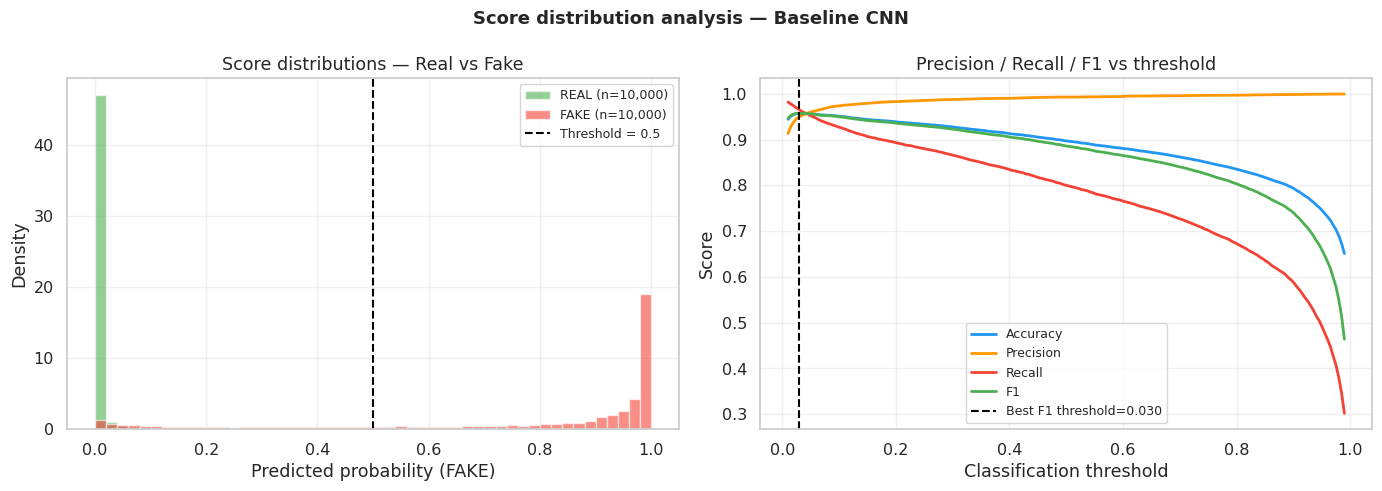

Optimal threshold (F1-maximizing): 0.0297
At optimal threshold:
  Accuracy  : 0.9572
  F1        : 0.9576
  Precision : 0.9497
  Recall    : 0.9655


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Score distribution analysis — Baseline CNN', fontsize=13, fontweight='bold')

real_scores = test_probs[test_labels == 0]
fake_scores = test_probs[test_labels == 1]

# Histogram
axes[0].hist(real_scores, bins=50, density=True, alpha=0.6,
             color='#4CAF50', label=f'REAL (n={len(real_scores):,})')
axes[0].hist(fake_scores, bins=50, density=True, alpha=0.6,
             color='#F44336', label=f'FAKE (n={len(fake_scores):,})')
axes[0].axvline(0.5, color='black', linestyle='--',
                linewidth=1.5, label='Threshold = 0.5')
axes[0].set_xlabel('Predicted probability (FAKE)')
axes[0].set_ylabel('Density')
axes[0].set_title('Score distributions — Real vs Fake')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Threshold sweep
thresholds = np.linspace(0.01, 0.99, 200)
accs, precs, recs, f1s = [], [], [], []
for t in thresholds:
    p = (test_probs >= t).astype(int)
    accs.append(accuracy_score(test_labels, p))
    precs.append(precision_score(test_labels, p, zero_division=0))
    recs.append(recall_score(test_labels, p, zero_division=0))
    f1s.append(f1_score(test_labels, p, zero_division=0))

best_thresh_idx = np.argmax(f1s)
best_thresh     = thresholds[best_thresh_idx]

axes[1].plot(thresholds, accs,  color='#2196F3', linewidth=2, label='Accuracy')
axes[1].plot(thresholds, precs, color='#FF9800', linewidth=2, label='Precision')
axes[1].plot(thresholds, recs,  color='#F44336', linewidth=2, label='Recall')
axes[1].plot(thresholds, f1s,   color='#4CAF50', linewidth=2, label='F1')
axes[1].axvline(best_thresh, color='black', linestyle='--',
                linewidth=1.5, label=f'Best F1 threshold={best_thresh:.3f}')
axes[1].set_xlabel('Classification threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 vs threshold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'baseline_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Optimal threshold (F1-maximizing): {best_thresh:.4f}')
print(f'At optimal threshold:')
opt_preds = (test_probs >= best_thresh).astype(int)
print(f'  Accuracy  : {accuracy_score(test_labels, opt_preds):.4f}')
print(f'  F1        : {f1_score(test_labels, opt_preds):.4f}')
print(f'  Precision : {precision_score(test_labels, opt_preds):.4f}')
print(f'  Recall    : {recall_score(test_labels, opt_preds):.4f}')

---
## Feature Map Visualization

### What the CNN actually learned

Visualizing the activation maps of the first convolutional layer reveals what low-level patterns the model learned to detect. Unlike ImageNet-pretrained models where the first layer learns clean Gabor-like filters (oriented edges), a scratch-trained CNN learns whatever patterns are most discriminative in this specific dataset.

If the model learned forensically relevant features, you would expect to see:
- Filters that respond to noise patterns (small random perturbations)
- Filters that respond to texture irregularities (LBP-like patterns)
- Filters that respond to smooth gradients (detecting AI over-smoothness)

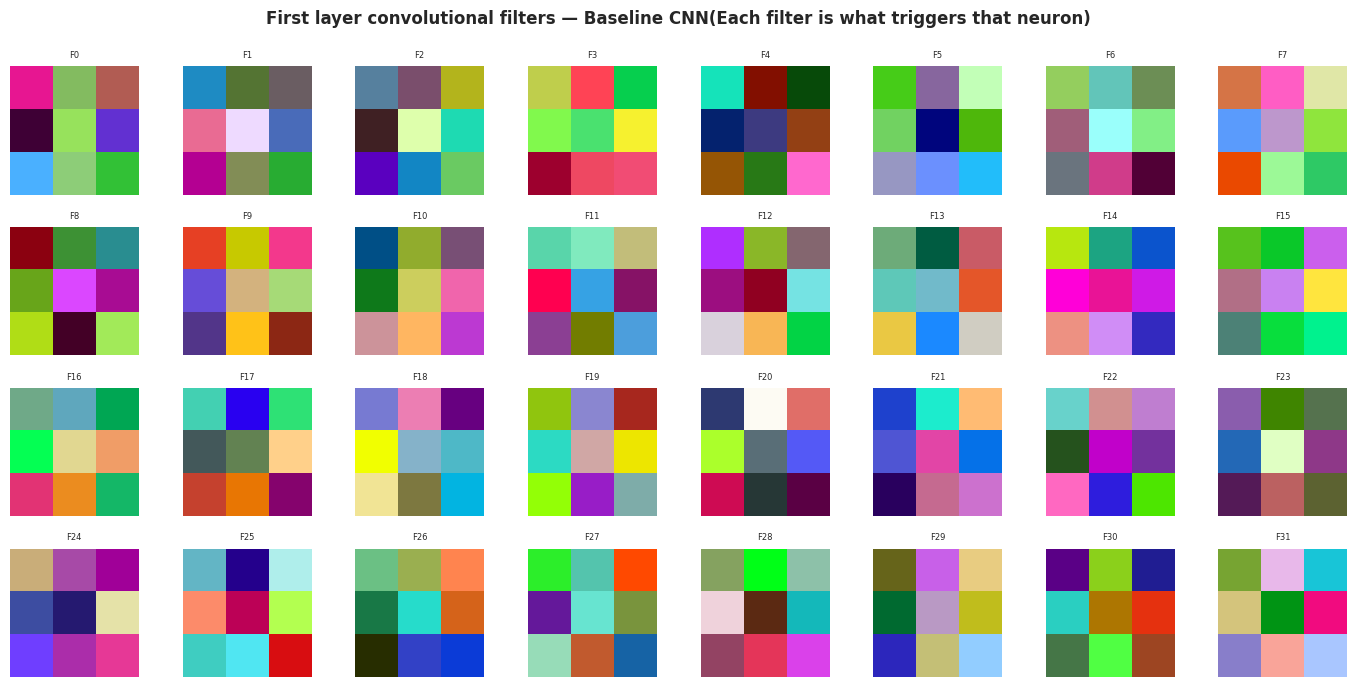

32 learned filters from first convolutional layer.
Compare to Task 3 — pretrained filters look more structured (Gabor-like).


In [14]:
# Visualize first-layer conv filters
first_conv_weights = model.features[0].block[0].weight.data.cpu()
# Shape: (out_channels, in_channels, H, W) = (32, 3, 3, 3)

# Normalize each filter for visualization
def normalize_filter(f):
    f = f - f.min()
    f = f / (f.max() + 1e-8)
    return f

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle('First layer convolutional filters — Baseline CNN'
             '(Each filter is what triggers that neuron)',
             fontsize=12, fontweight='bold')

for idx in range(32):
    ax  = axes[idx // 8, idx % 8]
    flt = first_conv_weights[idx].permute(1, 2, 0).numpy()
    flt = normalize_filter(flt)
    ax.imshow(flt)
    ax.axis('off')
    ax.set_title(f'F{idx}', fontsize=6)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'baseline_filters.png', dpi=150, bbox_inches='tight')
plt.show()
print('32 learned filters from first convolutional layer.')
print('Compare to Task 3 — pretrained filters look more structured (Gabor-like).')

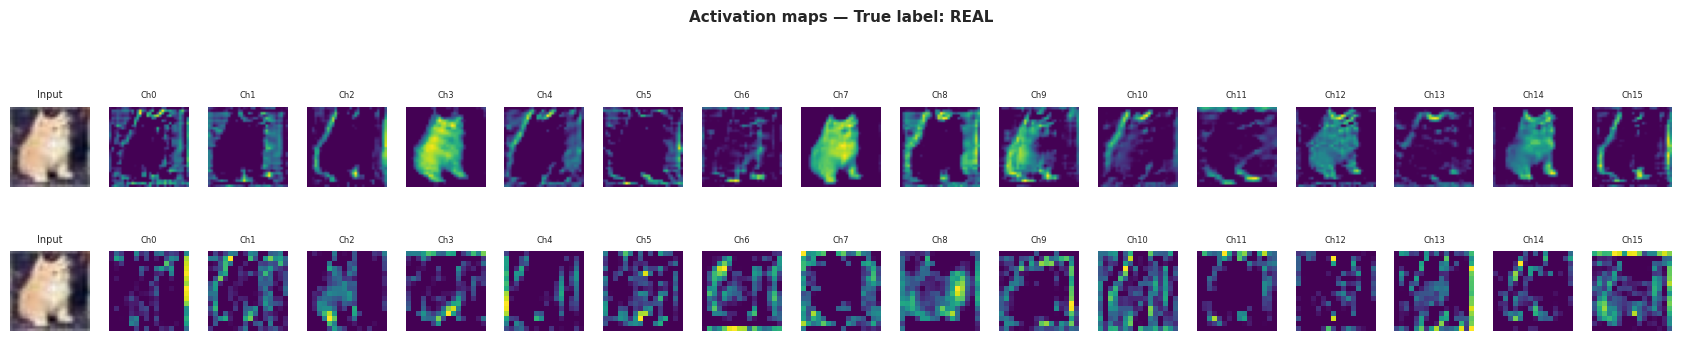

In [15]:
# Activation maps for a sample image
model.eval()
sample_img_tensor, sample_label = test_ds[42]
inp = sample_img_tensor.unsqueeze(0).to(DEVICE)

activation_maps = {}
def hook_fn(module, input, output, name):
    activation_maps[name] = output.detach().cpu()

hooks = []
hooks.append(model.features[0].block[2].register_forward_hook(
    lambda m, i, o: hook_fn(m, i, o, 'block1_relu1')))
hooks.append(model.features[1].block[2].register_forward_hook(
    lambda m, i, o: hook_fn(m, i, o, 'block2_relu1')))

with torch.no_grad():
    _ = model(inp)

for h in hooks:
    h.remove()

fig, axes = plt.subplots(2, 17, figsize=(17, 4))
fig.suptitle(f'Activation maps — True label: {"REAL" if sample_label==0 else "FAKE"}',
             fontsize=11, fontweight='bold')

orig_img = sample_img_tensor.permute(1, 2, 0).numpy()
orig_img = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min())

for row, (name, maps) in enumerate(list(activation_maps.items())[:2]):
    axes[row, 0].imshow(orig_img)
    axes[row, 0].axis('off')
    axes[row, 0].set_title('Input', fontsize=7)

    n_show = min(16, maps.shape[1])
    for i in range(n_show):
        ax = axes[row, i + 1]
        ax.imshow(maps[0, i].numpy(), cmap='viridis')
        ax.axis('off')
        ax.set_title(f'Ch{i}', fontsize=6)
    axes[row, 0].set_ylabel(name.replace('_', ' '), fontsize=7, rotation=90)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'baseline_activation_maps.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Save Results and Benchmark

### What the baseline tells us about Task 3

The baseline accuracy/AUC establishes the minimum performance bar. Any pretrained model that cannot beat this number on the same test set is not worth using. The gap between baseline and pretrained performance quantifies the value of transfer learning for forensic image detection.

In [16]:
# Save baseline results
baseline_results = {
    'model':          'Baseline CNN (from scratch)',
    'parameters':     trainable_params,
    'epochs_trained': EPOCHS,
    'best_epoch':     best_epoch,
    'test_accuracy':  float(final_metrics['accuracy']),
    'test_auc':       float(final_metrics['auc']),
    'test_f1':        float(final_metrics['f1']),
    'test_precision': float(final_metrics['precision']),
    'test_recall':    float(final_metrics['recall']),
    'best_val_auc':   float(best_auc),
    'opt_threshold':  float(best_thresh),
}

with open(OUTPUT_DIR / 'baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)

print('=== BASELINE CNN — FINAL BENCHMARK ===')
print()
print(f'  Architecture   : 4-block CNN, GlobalAvgPool')
print(f'  Parameters     : {trainable_params:,}')
print(f'  Training time  : {elapsed/60:.1f} min')
print()
print(f'  Test Accuracy  : {final_metrics["accuracy"]:.4f}')
print(f'  Test AUC       : {final_metrics["auc"]:.4f}')
print(f'  Test F1        : {final_metrics["f1"]:.4f}')
print(f'  Precision      : {final_metrics["precision"]:.4f}')
print(f'  Recall         : {final_metrics["recall"]:.4f}')
print()
print(f'TASK 3 TARGET: Beat AUC={final_metrics["auc"]:.4f} with EfficientNet transfer learning')
print()
print('Files saved:')
for f in ['baseline_cnn_best.pth','baseline_results.json',
          'baseline_training_curves.png','baseline_cnn_evaluation.png',
          'baseline_score_distribution.png','baseline_filters.png',
          'baseline_activation_maps.png']:
    size = (OUTPUT_DIR/f).stat().st_size/1024
    print(f'  {f:<45} {size:>8.1f} KB')
print()
print('Pass baseline_results.json to Task 3 as the comparison baseline.')

=== BASELINE CNN — FINAL BENCHMARK ===

  Architecture   : 4-block CNN, GlobalAvgPool
  Parameters     : 1,239,777
  Training time  : 68.0 min

  Test Accuracy  : 0.8973
  Test AUC       : 0.9922
  Test F1        : 0.8863
  Precision      : 0.9929
  Recall         : 0.8004

TASK 3 TARGET: Beat AUC=0.9922 with EfficientNet transfer learning

Files saved:
  baseline_cnn_best.pth                           4872.9 KB
  baseline_results.json                              0.3 KB
  baseline_training_curves.png                     192.5 KB
  baseline_cnn_evaluation.png                      102.0 KB
  baseline_score_distribution.png                  134.5 KB
  baseline_filters.png                              37.5 KB
  baseline_activation_maps.png                      86.6 KB

Pass baseline_results.json to Task 3 as the comparison baseline.


---
## Summary — What Task 2 Produced

### Key concept demonstrated

The baseline CNN learns macro-level differences between real and fake images — broad color statistics, coarse texture patterns, global saturation differences. It achieves solid performance because CIFAKE is a well-separated dataset.

What it **cannot** learn without pretraining:
- Fine-grained noise residual patterns (camera sensor vs diffusion artifacts)
- Precise frequency domain signatures (the 1/f power law deviation)
- Universal low-level texture detectors that generalize across image types

The first convolutional layer filters reveal this directly: scratch-trained filters look noisy and irregular. ImageNet-pretrained filters look like clean Gabor wavelets — oriented edge detectors that are universally useful for texture analysis.

### Files for Task 3

| File | Purpose |
|---|---|
| `baseline_cnn_best.pth` | Best baseline model weights |
| `baseline_results.json` | Benchmark metrics — Task 3 must beat these |
| `baseline_training_curves.png` | Loss, accuracy, AUC, LR history |
| `baseline_cnn_evaluation.png` | Confusion matrix + ROC curve |
| `baseline_score_distribution.png` | Score histograms + threshold sweep |
| `baseline_filters.png` | First-layer learned filters |
| `baseline_activation_maps.png` | Feature maps for a sample image |

---
**Next:** Task 3 — Transfer Learning with EfficientNet. Two-phase training: freeze backbone → train head, then unfreeze top layers → fine-tune. Expected accuracy improvement: +5-10% over baseline.

In [17]:
import shutil

shutil.make_archive('/kaggle/working/fake_detection_outputs', 'zip', '/kaggle/working/')

'/kaggle/working/fake_detection_outputs.zip'